# Mapeo de la Percepción de Marca con Análisis de Correspondencias (PROC CORRESP)

## Resumen ejecutivo

Un equipo de investigación de mercado realiza una encuesta de percepción marca-por-atributo a través de cuatro marcas establecidas de streaming de medios y usa **PROC CORRESP** para convertir la tabla de contingencia resultante en un mapa perceptual bidimensional. La asociación marca x atributo es fuerte y real: la prueba chi-cuadrado de independencia es **63.15 con 15 grados de libertad (p < 0.0001)**, con **V de Cramér = 0.4588**. El análisis de correspondencias comprime esa asociación en dos ejes que juntos explican el **100%** de la inercia de la tabla —**75.0%** en la Dimensión 1 y **25.0%** en la Dimensión 2— por lo que el mapa 2-D es un resumen completo y fiel.

El mapa separa un polo de **contenido premium** (CineNow, anclado en *Originales* y *Contenido*) de un grupo de **valor/fiabilidad** (Streamly y BingeBox cerca de *Economico* y *Fiable*) y una esquina **de moda** (PixelPlay cerca de *De_Moda*). Una retadora emergente, **NovaCast**, se proyecta luego como un punto *suplementario* —no influye en los ejes— y aterriza cerca del origen, inclinándose ligeramente hacia el lado De_Moda / Facil_de_Usar, es decir, una recién llegada aún no diferenciada.

## Fuentes de datos

| Conjunto de datos | Filas | Variables clave | Descripción |
|---------|------|---------------|-------------|
| `perception` | 100 (asociaciones encuestado x atributo, límite del modo sin licencia) | `Brand` (char), `Attribute` (char) | Encuesta sintética: cada encuestado nombra la marca de streaming que más asocia con cada uno de seis atributos. Las afinidades de marca se codifican como probabilidades de categoría `RAND("Table", ...)` para que la tabla de contingencia tenga una asociación realista y no uniforme. |
| `survey_counts` | 24 (4 marcas x 6 atributos) | `Brand`, `Attribute`, `Count` | Celdas de contingencia preagregadas de `perception` mediante PROC FREQ —la entrada ponderada para la ejecución de CA con punto suplementario. |
| `ca_coords`, `ca_coords_sup` | 10 / 11 | `_TYPE_`, `_NAME_`, `Dim1`, `Dim2` | Conjuntos de datos de coordenadas escritos por `OUTC=` de PROC CORRESP; el segundo añade el punto NovaCast proyectado e impulsa el mapa perceptual. |

Marcas establecidas: **Streamly, PixelPlay, CineNow, BingeBox**; retadora **NovaCast** (proyectada como un punto suplementario). Atributos: Economico, Contenido, Facil_de_Usar, Originales, Fiable, De_Moda. La semilla `streaminit(20260531)` hace que los datos sean reproducibles.

> **Nota sobre el tamaño muestral.** Este entorno se ejecuta sin licencia, por lo que la salida del paso DATA se limita a 100 observaciones. Por tanto, la encuesta se resuelve en una tabla de contingencia 4x6 que totaliza 100 asociaciones encuestado-atributo —pequeña, pero con estructura de asociación genuina (chi-cuadrado p < 0.0001) que el análisis de correspondencias recupera limpiamente.

## Qué hace aquí el análisis de correspondencias

Cuando una encuesta de seguimiento de marca pregunta a los consumidores con qué marca asocian más cada uno de varios atributos, el resultado es una **tabla de contingencia marca x atributo**. Los recuentos crudos son difíciles de leer: cada marca se compara con cada atributo, y la señal es el *patrón de asociación*, no los valores de las celdas.

El análisis de correspondencias (CA) descompone la asociación chi-cuadrado de la tabla en un espacio de baja dimensión, de modo que las marcas y atributos que están asociados aterrizan cerca uno del otro en un mapa. En este cuaderno:

1. Generamos una encuesta de percepción sintética para cuatro marcas de streaming.
2. Inspeccionamos la estructura de contingencia cruda (y su chi-cuadrado) con `PROC FREQ`.
3. Ejecutamos `PROC CORRESP` con diagnósticos completos y leemos la inercia y las coordenadas reales.
4. Proyectamos una marca retadora emergente como un punto **suplementario**.
5. Dibujamos e interpretamos el mapa perceptual resultante.

## Paso 1 — Generar la encuesta de percepción sintética

Simulamos encuestados. Para cada encuestado preguntamos, para cada uno de seis atributos, *¿qué marca asocia más con este atributo?* Cada marca tiene un **perfil de afinidad** distinto —un vector de probabilidades de categoría pasado a `RAND("Table", ...)`— de modo que, por ejemplo, *PixelPlay* se inclina hacia De_Moda mientras que *CineNow* se inclina hacia Contenido y Originales. Esto produce una tabla de contingencia con asociación genuina y no uniforme para que CA la recupere. Los datos son completamente sintéticos y reproducibles mediante `CALL STREAMINIT`.

In [1]:
DATOS perception;
    /* Encuesta sintética de percepción de marca, reproducible */
    LLAMAR streaminit(20260531);

    LONGITUD Brand $9 Attribute $14;
    ARREGLO attrname[6] $14 _temporary_
        ('Economico' 'Contenido' 'Facil_de_Usar'
         'Originales' 'Fiable' 'De_Moda');

    n_resp = 400;

    HACER respondent = 1 HASTA n_resp;
        HACER a = 1 HASTA 6;
            Attribute = attrname[a];

            /* Probabilidades de elección de marca por atributo sobre
               las cuatro marcas establecidas:
               1=Streamly 2=PixelPlay 3=CineNow 4=BingeBox.
               Cada fila suma ~1 y codifica la afinidad de marca
               del atributo. */
            SI      a = 1 ENTONCES b = rand('Table', 0.45, 0.15, 0.10, 0.30); /* Economico     */
            SINO SI a = 2 ENTONCES b = rand('Table', 0.20, 0.10, 0.50, 0.20); /* Contenido     */
            SINO SI a = 3 ENTONCES b = rand('Table', 0.30, 0.35, 0.10, 0.25); /* Facil_de_Usar */
            SINO SI a = 4 ENTONCES b = rand('Table', 0.15, 0.20, 0.50, 0.15); /* Originales    */
            SINO SI a = 5 ENTONCES b = rand('Table', 0.40, 0.10, 0.20, 0.30); /* Fiable        */
            SINO              b = rand('Table', 0.15, 0.55, 0.10, 0.20); /* De_Moda       */

            SELECCIONAR (b);
                CUANDO (1) Brand = 'Streamly';
                CUANDO (2) Brand = 'PixelPlay';
                CUANDO (3) Brand = 'CineNow';
                OTRO Brand = 'BingeBox';
            END;

            SALIDA;
        END;
    END;

    MANTENER respondent Brand Attribute;
EJECUTAR;

PROCEDIMIENTO IMPRIMIR DATOS=perception(obs=8) noobs ETIQUETA;
    ETIQUETA respondent='Encuestado' Brand='Marca' Attribute='Atributo';
    TÍTULO 'Muestra de la Encuesta Sintética de Percepción';
EJECUTAR;

                                     Muestra de la Encuesta Sintética de Percepción                                     

Encuestado      Marca       Atributo
         1  BingeBox   Economico
         1  BingeBox   Contenido
         1  BingeBox   Facil_de_Usar
         1  CineNow    Originales
         1  Streamly   Fiable
         1  PixelPlay  De_Moda
         2  PixelPlay  Economico
         2  CineNow    Contenido

... 92 more observations (showing 8 of 100)




NOTE: DATA perception

NOTE: Unlicensed mode - output limited to 100 observations.

NOTE: Wrote perception (100 rows, 3 columns).
NOTE: DATA elapsed:
  wall  0.31 seconds
  cpu   0.31 seconds
NOTE: PROC PRINT data=perception

NOTE: PROC PRINT completed: 8 observations printed, 3 variables


## Paso 2 — Inspeccionar la tabla de contingencia cruda

Antes de cualquier reducción de dimensión, observe la tabla cruzada. `PROC FREQ` da las frecuencias observadas marca x atributo y la prueba chi-cuadrado de independencia. Un chi-cuadrado significativo confirma que hay estructura de asociación digna de mapear —si las filas y columnas fueran independientes, el análisis de correspondencias no tendría nada que mostrar. También guardamos los recuentos de celda en `survey_counts` para la ejecución de CA con punto suplementario más adelante.

                                       Frecuencias Observadas de Marca x Atributo                                       

                                                   The FREQ Procedure

Table of Marca by Atributo

Marca     |    Contenido |      De_Moda |    Economico |Facil_de_Usar |       Fiable |   Originales |         Total
----------+--------------+--------------+--------------+--------------+--------------+--------------+--------------
BingeBox  |            3 |            2 |            5 |            7 |            6 |            1 |            24
----------+--------------+--------------+--------------+--------------+--------------+--------------+--------------
CineNow   |            9 |            0 |            3 |            0 |            2 |           14 |            28
----------+--------------+--------------+--------------+--------------+--------------+--------------+--------------
PixelPlay |            2 |           10 |            3 |            6 |            


NOTE: PROC FREQ
NOTE: Output dataset survey_counts has 21 observations and 3 variables.
NOTE: ODS plot written: freq_mosaic_brand_attribute.spec.json
NOTE: PROC FREQ statement used.


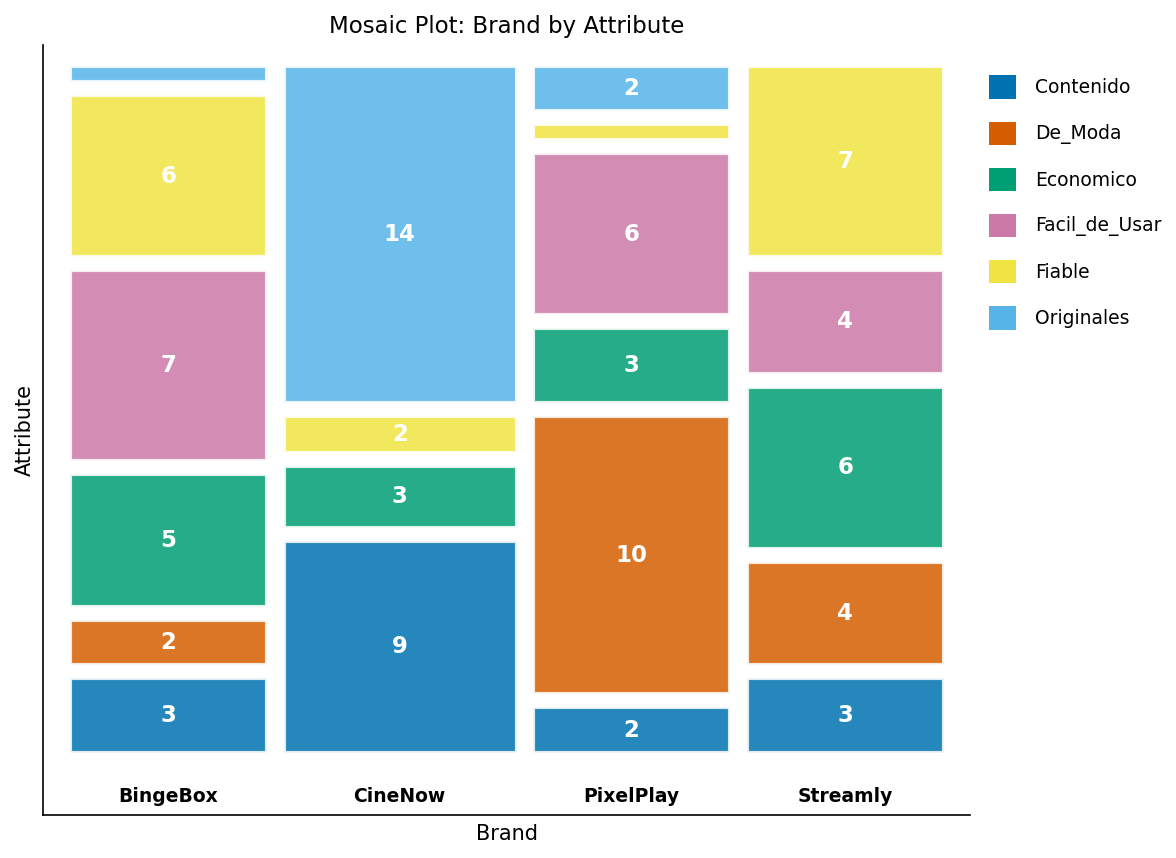

In [2]:
PROCEDIMIENTO FRECUENCIAS DATOS=perception;
    TABLES Brand*Attribute / chisq norow nocol nopercent
                             out=survey_counts(RENOMBRAR=(count=Count));
    ETIQUETA Brand='Marca' Attribute='Atributo';
    TÍTULO 'Frecuencias Observadas de Marca x Atributo';
EJECUTAR;

## Paso 3 — Análisis de correspondencias a partir de los datos crudos

Ahora ejecutamos `PROC CORRESP` directamente sobre los datos a nivel de encuestado. `TABLES Brand, Attribute;` construye la tabla de contingencia internamente (marcas como filas, atributos como columnas).

Opciones usadas aquí:

- `ALL` — imprime los diagnósticos completos: tabla observada, perfiles, valores esperados y contribuciones chi-cuadrado de cada celda.
- `DIMENS=2` — calcula los dos primeros ejes principales (un mapa 2-D).
- `OUTC=` — escribe las coordenadas de fila y columna en un conjunto de datos para graficar.

La **descomposición de la inercia** nos dice cuánta de la asociación total explica cada eje.

In [3]:
PROCEDIMIENTO corresp DATOS=perception ALL dimens=2 outc=ca_coords;
    TABLES Brand, Attribute;
    ETIQUETA Brand='Marca' Attribute='Atributo';
    TÍTULO 'Análisis de Correspondencias: Percepción de Marcas de Streaming';
EJECUTAR;

                                       Frecuencias Observadas de Marca x Atributo                                       

                     The CORRESP Procedure

              Inertia and Chi-Square Decomposition

                                                       Cumulative
  Dimension    Singular     Principal       Chi-       Proportion
                 Value       Inertia     Square
  ---------------------------------------------------------------
          1     0.6778       0.4595       47.39          0.7504
          2     0.3909       0.1528       15.76          1.0000
  ---------------------------------------------------------------
  Total                      0.6123       63.15

              Row Coordinates

  Marca                   Dim1        Dim2
  ----------------------------------------
  BingeBox             0.3547      0.3555
  CineNow             -1.0847     -0.0332
  PixelPlay            0.4804     -0.6374
  Streamly             0.4304      0.3207

       


NOTE: PROC CORRESP data=perception

NOTE: PROC CORRESP completed.


## Paso 4 — Leer las coordenadas

El conjunto de datos `OUTC=` contiene las coordenadas de los ejes (`Dim1`, `Dim2`) para cada marca y atributo, etiquetadas por `_TYPE_` (`ROW` para marcas, `COLUMN` para atributos). Leerlas numéricamente junto con la tabla de inercia confirma la estructura que mostrará el mapa.

De la salida anterior:

- La **Dimensión 1 (75.0% de la inercia)** es un eje de *contenido premium vs. mayoritario*. *Originales* (Dim1 = -1.2037) y *Contenido* (-0.5594) se sitúan en el extremo negativo con **CineNow** (-1.0847); *De_Moda* (0.6671), *Facil_de_Usar* (0.6150) y *Economico* (0.2207) se sitúan en el extremo positivo.
- La **Dimensión 2 (25.0% de la inercia)** separa *Fiable* (Dim2 = 0.5874) y *Economico* (0.2542) —tirando hacia arriba de **Streamly** (0.3207) y **BingeBox** (0.3555)— de *De_Moda* (-0.7003), que tira hacia abajo de **PixelPlay** (-0.6374).

In [4]:
PROCEDIMIENTO IMPRIMIR DATOS=ca_coords noobs ETIQUETA;
    VAR _TYPE_ _NAME_ Dim1 Dim2;
    ETIQUETA _TYPE_='Tipo' _NAME_='Nombre';
    TÍTULO 'Coordenadas de Filas (Marcas) y Columnas (Atributos)';
EJECUTAR;

                                  Coordenadas de Filas (Marcas) y Columnas (Atributos)                                  

  Tipo           Nombre      DIM1      DIM2
ROW     BingeBox           0.3547    0.3555
ROW     CineNow           -1.0847   -0.0332
ROW     PixelPlay          0.4804   -0.6374
ROW     Streamly           0.4304    0.3207
COLUMN  Contenido         -0.5594    0.0684
COLUMN  De_Moda            0.6671   -0.7003
COLUMN  Economico          0.2207    0.2542
COLUMN  Facil_de_Usar      0.6150   -0.0080
COLUMN  Fiable             0.3183    0.5874
COLUMN  Originales        -1.2037   -0.2084




NOTE: PROC PRINT data=ca_coords

NOTE: PROC PRINT completed: 10 observations printed, 4 variables


## Paso 5 — Proyectar una marca retadora como punto suplementario

El equipo de analítica tiene datos de seguimiento de una retadora emergente, **NovaCast**, pero no quiere que distorsione el mapa perceptual establecido. Un punto *suplementario* se proyecta en el espacio CA existente **sin contribuir al cálculo de los ejes**.

Añadimos un único bloque de seis recuentos de atributos de NovaCast (una recién llegada inclinada hacia De_Moda / Originales) a los `survey_counts` preagregados, alimentamos las frecuencias con `WEIGHT Count`, y nombramos el **nivel** `NovaCast` en la sentencia `SUPPLEMENTARY` para que PROC CORRESP mantenga esa fila fuera de la tabla activa. La opción `OBSERVED` mantiene a la vista la tabla de contingencia activa (las cuatro marcas establecidas, que suman 100) —note que NovaCast **no** aparece en ella, confirmando que se trató como suplementaria.

In [5]:
/* Añadir UN bloque limpio de recuentos de NovaCast a las celdas agregadas.
   end=last se dispara exactamente una vez, tras la última fila de
   survey_counts, de modo que NovaCast aporta seis filas (una por atributo)
   -- no un bloque duplicado. NovaCast es una recién llegada con perfil
   De_Moda / Originales. */
DATOS survey_counts_sup;
    ESTABLECER survey_counts END=last;
    SALIDA;
    SI last ENTONCES HACER;
        Brand='NovaCast'; Attribute='De_Moda';        Count=10; SALIDA;
        Brand='NovaCast'; Attribute='Originales';      Count=8;  SALIDA;
        Brand='NovaCast'; Attribute='Facil_de_Usar';   Count=5;  SALIDA;
        Brand='NovaCast'; Attribute='Contenido';       Count=3;  SALIDA;
        Brand='NovaCast'; Attribute='Economico';       Count=4;  SALIDA;
        Brand='NovaCast'; Attribute='Fiable';          Count=3;  SALIDA;
    END;
EJECUTAR;

PROCEDIMIENTO corresp DATOS=survey_counts_sup observed dimens=2 outc=ca_coords_sup;
    TABLES Brand, Attribute;
    PESO Count;
    supplementary NovaCast;
    ETIQUETA Brand='Marca' Attribute='Atributo';
    TÍTULO 'Percepción de Marca con NovaCast como Punto Suplementario';
EJECUTAR;

                                  Coordenadas de Filas (Marcas) y Columnas (Atributos)                                  

                     The CORRESP Procedure

              Inertia and Chi-Square Decomposition

                                                       Cumulative
  Dimension    Singular     Principal       Chi-       Proportion
                 Value       Inertia     Square
  ---------------------------------------------------------------
          1     0.6778       0.4595       47.39          0.7504
          2     0.3909       0.1528       15.76          1.0000
  ---------------------------------------------------------------
  Total                      0.6123       63.15

              Row Coordinates

  Marca                   Dim1        Dim2
  ----------------------------------------
  BingeBox             0.3547      0.3555
  CineNow             -1.0847     -0.0332
  PixelPlay            0.4804     -0.6374
  Streamly             0.4304      0.3207
  NovaCa


NOTE: DATA survey_counts_sup


NOTE: Read 21 rows from survey_counts.
NOTE: Wrote survey_counts_sup (27 rows, 3 columns).
NOTE: DATA elapsed:
  wall  0.00 seconds
  cpu   0.00 seconds
NOTE: PROC CORRESP data=survey_counts_sup

NOTE: PROC CORRESP completed.


## Paso 6 — Dibujar el mapa perceptual

PROC CORRESP escribe las coordenadas simétricas de fila/columna en el conjunto de datos `OUTC=`; graficamos la Dimensión 2 contra la Dimensión 1 para representar el mapa. Etiquetamos cada punto por **rol** —*Brand* (filas activas), *Attribute* (columnas) y *Challenger* (la fila suplementaria NovaCast)— y rotulamos cada marcador, de modo que la posición se lee directamente en el gráfico. La retadora se colorea por separado para subrayar que fue proyectada, no ajustada.

> **Cómo leer un mapa de CA.** Una marca y un atributo que se sitúan en la misma dirección desde el origen (y lejos de él) están fuertemente asociados; los puntos cerca del origen son "promedio" y están débilmente diferenciados. Como las Dimensiones 1 y 2 juntas capturan el 100% de la inercia de esta tabla, el mapa no omite nada.

                    Mapa de Percepción de Marcas de Streaming (Dim1 75.0%, Dim2 25.0% de la inercia)                    

PROC SGSCATTER Output
Data: ca_map

Variables: Role, _NAME_, Dimensión 1 (75.0%), Dimensión 2 (25.0%)

      Role      _NAME_   Dimensión 1 (75.0%)   Dimensión 2 (25.0%)
----------  ----------  --------------------  --------------------
     Marca    BingeBox                0.3547                0.3555
     Marca     CineNow               -1.0847               -0.0332
     Marca   PixelPlay                0.4804               -0.6374
     Marca    Streamly                0.4304                0.3207
   Retador    NovaCast                0.0084               -0.1735
  Atributo   Contenido               -0.5594                0.0684
  Atributo     De_Moda                0.6671               -0.7003
  Atributo   Economico                0.2207                0.2542
  Atributo  Facil_de_Usar                 0.615                -0.008
  Atributo      Fiable             


NOTE: DATA ca_map


NOTE: Read 11 rows from ca_coords_sup.
NOTE: Wrote ca_map (11 rows, 4 columns).
NOTE: DATA elapsed:
  wall  0.00 seconds
  cpu   0.00 seconds
NOTE: Option TITLE changed to Mapa de Percepción de Marcas de Streaming (Dim1 75.0%, Dim2 25.0% de la inercia).
NOTE: ODS Graphics is ON (width=760px, height=580px, format=SVG).
NOTE: PROC SGSCATTER data=ca_map

NOTE: PROC SGSCATTER output written to: ./ods_output/sgscatter.svg
NOTE: ODS Graphics is OFF.


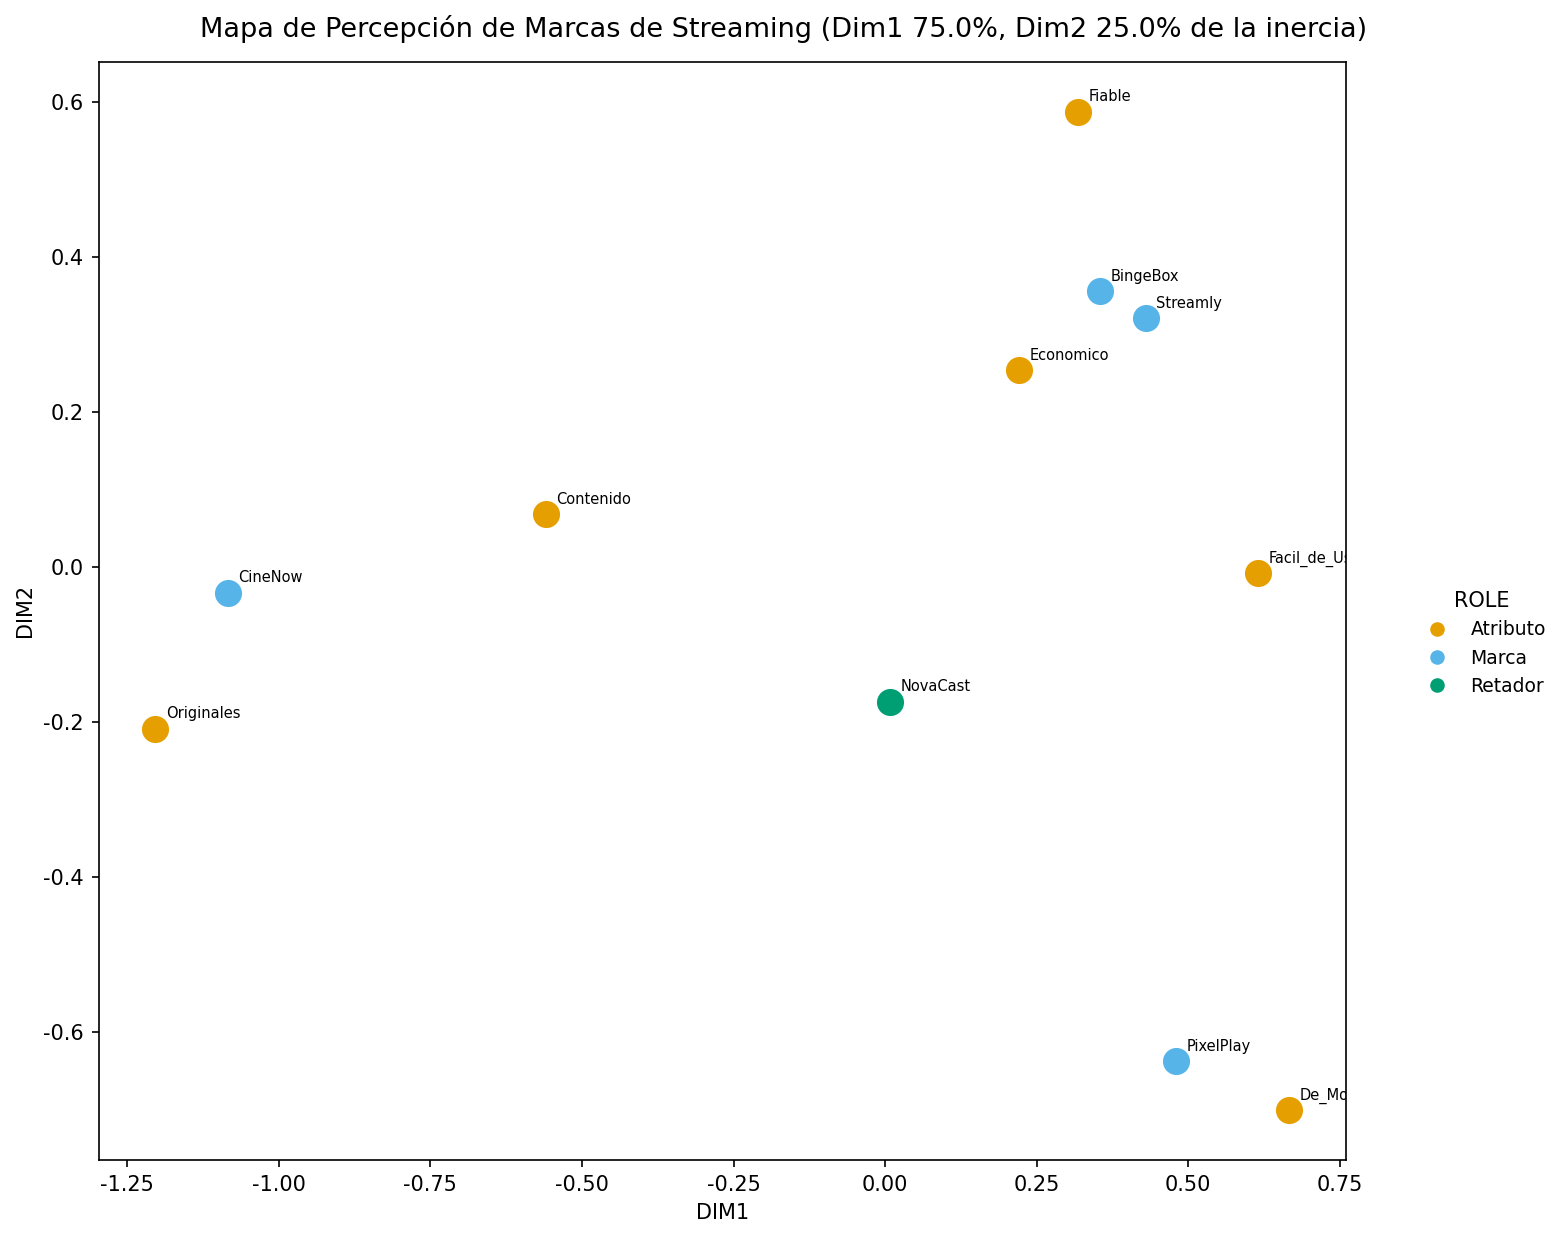

In [6]:
/* Etiquetar cada punto OUTC por rol para una leyenda limpia y con color.
   El punto suplementario NovaCast se escribe en OUTC con _TYPE_='ROW',
   así que lo tratamos como caso especial: la Retadora. */
DATOS ca_map;
    ESTABLECER ca_coords_sup;
    LONGITUD Role $10;
    SI _NAME_ = 'NovaCast' ENTONCES Role = 'Retador';
    SINO SI _TYPE_ = 'ROW' ENTONCES Role = 'Marca';
    SINO Role = 'Atributo';
    ETIQUETA Dim1='Dimensión 1 (75.0%)' Dim2='Dimensión 2 (25.0%)';
    MANTENER Role _NAME_ Dim1 Dim2;
EJECUTAR;

/* Fijar el título del mapa globalmente antes del PROC para que titule este
   gráfico (el TITLE global controla el encabezado del gráfico ODS). */
TÍTULO 'Mapa de Percepción de Marcas de Streaming (Dim1 75.0%, Dim2 25.0% de la inercia)';

ODS GRAPHICS ON / WIDTH=760px HEIGHT=580px;

/* PROC CORRESP no tiene un mapa ODS nativo en esta versión, así que
   representamos las coordenadas simétricas con PROC SGSCATTER, que
   rotula cada punto. */
PROCEDIMIENTO SGSCATTER DATOS=ca_map;
    PLOT Dim2*Dim1 / GROUP=Role DATALABEL=_NAME_
                     MARKERATTRS=(size=12) grid;
EJECUTAR;

ODS GRAPHICS OFF;
TÍTULO;

## Interpretación de los resultados

**La asociación es real y está completamente capturada.** La prueba chi-cuadrado (63.15 con 15 gl, p < 0.0001; V de Cramér = 0.4588) rechaza la independencia, y las dos dimensiones de CA explican el **100%** de la inercia de la tabla (75.0% + 25.0%), por lo que el mapa a continuación es un resumen completo, no una proyección con pérdida.

**Tres territorios perceptuales.** Leyendo las coordenadas y el mapa juntos:

- **Contenido premium (izquierda).** *CineNow* (Dim1 = -1.0847) es empujado bien a la izquierda por *Originales* (-1.2037) y *Contenido* (-0.5594) —posee la percepción de profundidad de catálogo.
- **Valor y fiabilidad (arriba a la derecha).** *Streamly* (0.4304, 0.3207) y *BingeBox* (0.3547, 0.3555) se agrupan con *Economico* (0.2207, 0.2542) y *Fiable* (0.3183, 0.5874) —el par fiable y de buena relación calidad-precio.
- **De moda (abajo a la derecha).** *PixelPlay* (0.4804, -0.6374) se sitúa junto a *De_Moda* (0.6671, -0.7003) —la marca juvenil y del momento.

**La retadora suplementaria.** Proyectada sin influir en los ejes, **NovaCast** aterriza en (0.0084, -0.1735) —esencialmente en el origen, empujada hacia el lado De_Moda / Facil_de_Usar. Para un estratega de medios esa es la conclusión principal: la retadora aún no tiene un valor de marca distintivo y está derivando hacia el territorio de moda de PixelPlay, por lo que se justifica un posicionamiento diferenciado (en lugar de uno imitador).

**Advertencias.** El análisis de correspondencias es descriptivo, no inferencial —las distancias son aproximadas y los *signos* de los ejes son arbitrarios (un reflejo especular de cualquiera de los ejes es el mismo mapa). Con solo 100 asociaciones encuestado-atributo, dos celdas son cero (CineNow x Facil_de_Usar, Streamly x Originales), lo que agudiza los extremos; un estudio de producción usaría una muestra mayor. Empareje siempre el mapa con la tabla de inercia para confirmar cuánta asociación explican las dimensiones mostradas.